In [1]:
import numpy as np
from scipy import stats
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import format_chronic_stim
import format_waveform_data
import waveform_analysis

import scipy.io
import os

In [2]:
''' set paths '''
# set directories
temp_local_root = "C:/Users/ilow1/Documents/code/lhy_hpc/data/"
save_dir = f"../figures/basic_neural_analysis/"

In [2]:
# set parent directory
root_dir = "Z:/Isabel/data/hpc_implants/"

# session params
bird_id = "LIM63"
session_id = "240610"
ephys_id = "LIM63_240610_131820"
show_plots = False

# data directories
session_dir = f"{root_dir}{bird_id}/{bird_id}_{session_id}/{ephys_id}/"
ks_dir = "kilosort4_hash_blanked/"
ephys_dir = "raw_ephys_output/"

# set save folder
save_dir = f"../figures/basic_neural_analysis/{bird_id}/"
save_folder = f"{save_dir}{bird_id}_{session_id}/"
if os.path.isdir(save_folder):
    print('save folder exists')
else:
    if os.path.isdir(save_dir):
        os.mkdir(save_folder)
    else:
        os.mkdir(save_dir)
        os.mkdir(save_folder)

save folder exists


In [19]:
''' to run the analysis on lots of sessions '''
wf_dir = f"{temp_local_root}waveform_structs/"
wf_files = []
for f in os.listdir(wf_dir):
    wf_files.append(f)
wf_files = sorted(wf_files)
print(wf_files) # maybe don't want this

n_cells_total = 0 
all_fr = np.asarray([])
all_width = np.asarray([])
all_assym = np.asarray([])
for i, f in enumerate(wf_files):
    # load the struct
    wf_file_path = f"{wf_dir}{f}"
    waveform_struct = format_waveform_data.load_wf_multi_session(wf_file_path)
    
    # get the best waveform for each cell
    mean_waveforms = np.transpose(waveform_struct['waveFormsMean'], (2, 1, 0)) # reformat cells, channels, timpoints
    max_site = waveform_struct['max_site'] - 1 # fix matlab indexing
    
    # get the number of cells for this session
    n_cells = mean_waveforms.shape[0]
    n_cells_total += n_cells
    
    # get the waveform properties
    fr = waveform_struct['meanRate']
    width = np.zeros(n_cells)
    assym = np.zeros(n_cells)
    for wf_idx in range(n_cells):
        best_ch = max_site[wf_idx]
        width[wf_idx] = waveform_analysis.calc_spike_width(mean_waveforms[wf_idx, best_ch])
        assym[wf_idx] = waveform_analysis.calc_amp_assym(mean_waveforms[wf_idx, best_ch])    
        
    # store for all sessions
    if i == 0:
        all_waveforms = mean_waveforms
    else:
        all_waveforms = np.row_stack([all_waveforms, mean_waveforms])
    all_fr = np.append(all_fr, fr)
    all_width = np.append(all_width, width)
    all_assym = np.append(all_assym, assym)
    
# consolidate the params for clustering
wf_params = np.column_stack([all_assym, all_width])
wf_params = np.column_stack([wf_params, np.log10(all_fr)])

['LIM63_240610_waveformStruct.mat', 'SPP134_240715_waveformStruct.mat', 'SPP134_240719_waveformStruct.mat']
C:/Users/ilow1/Documents/code/lhy_hpc/data/waveform_structs/LIM63_240610_waveformStruct.mat
C:/Users/ilow1/Documents/code/lhy_hpc/data/waveform_structs/SPP134_240715_waveformStruct.mat
C:/Users/ilow1/Documents/code/lhy_hpc/data/waveform_structs/SPP134_240719_waveformStruct.mat


In [20]:
''' kmeans cluster on those parameters '''
kmeans = KMeans(n_clusters=2, n_init=100, random_state=1234)
kmeans.fit(wf_params)
H = kmeans.cluster_centers_
W_raw = kmeans.labels_

C:\Users\ilow1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [3]:
''' load and format the waveform struct '''
waveform_struct = format_waveform_data.load_wf_data(session_dir, ks_dir=ks_dir)
# mean_waveforms, max_ch, max_idx = format_waveform_data.sort_wf_by_channel(session_dir, waveform_struct, data_dir=ephys_dir)
mean_waveforms = np.transpose(waveform_struct['waveFormsMean'], (2, 1, 0))
n_cells = mean_waveforms.shape[0]

Z:/Isabel/data/hpc_implants/LIM63/LIM63_240610/LIM63_240610_131820/kilosort4_hash_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spkDur', 'spkOffset', 'goodIDs', 'goodLabels', 'medISI', 'contam', 'nSpikes'])


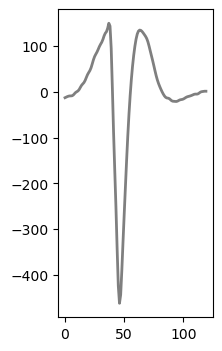

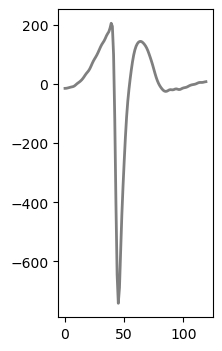

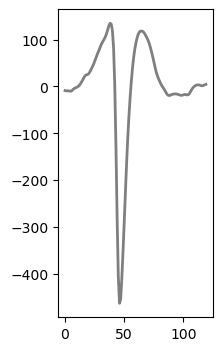

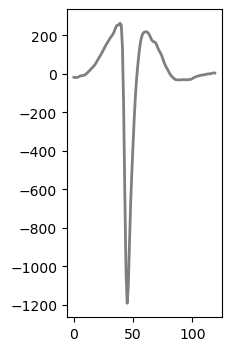

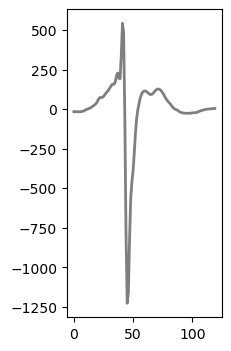

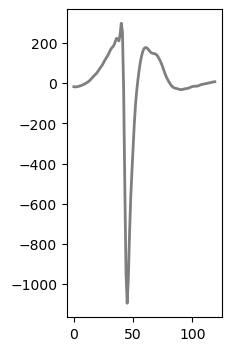

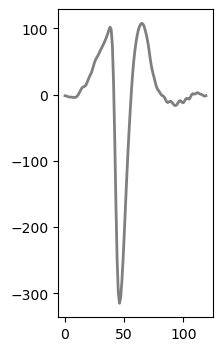

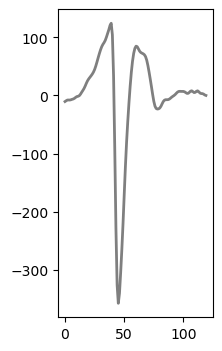

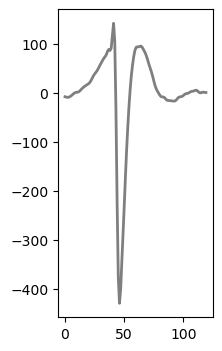

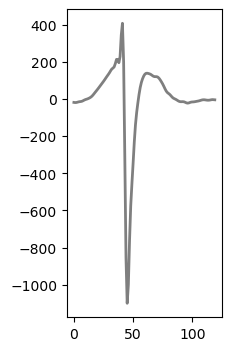

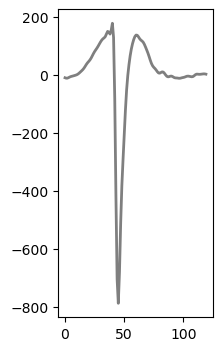

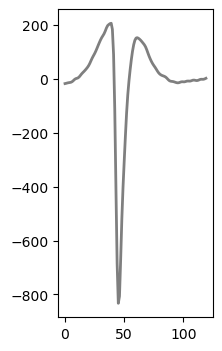

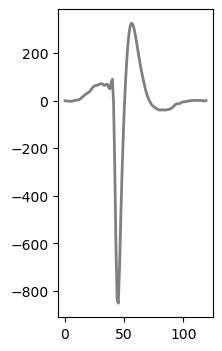

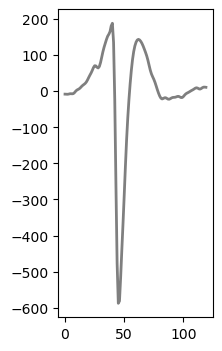

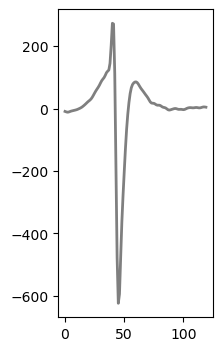

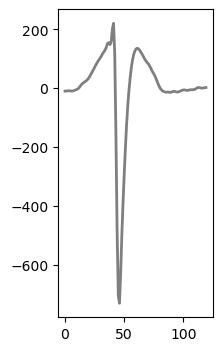

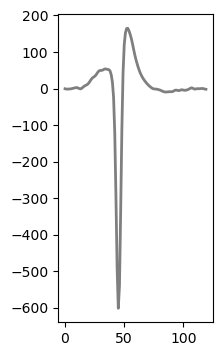

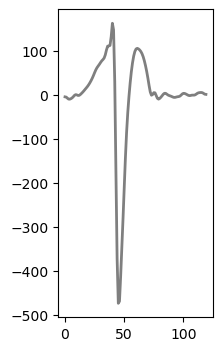

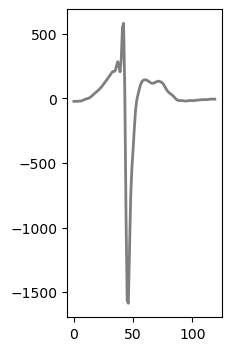

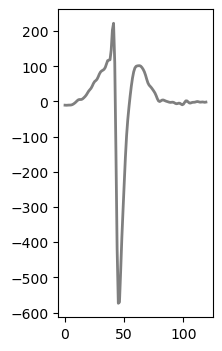

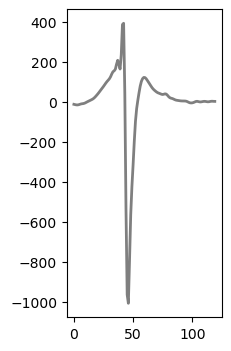

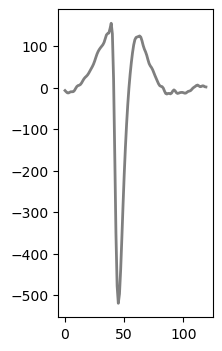

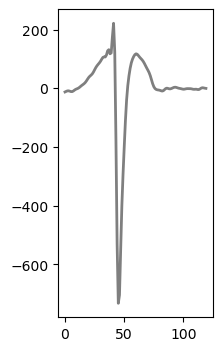

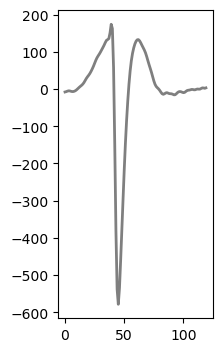

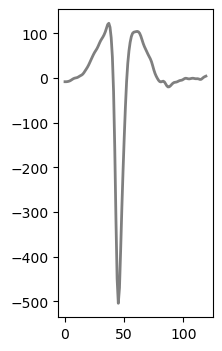

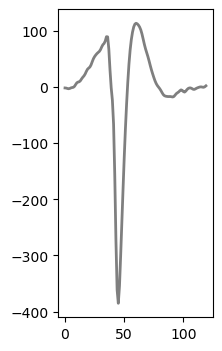

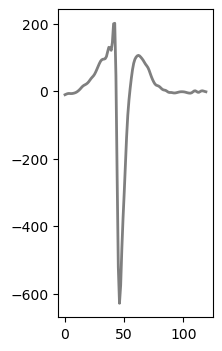

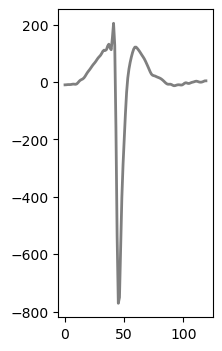

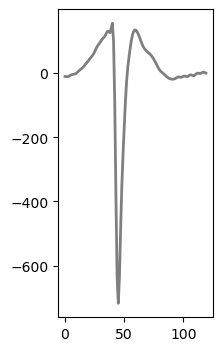

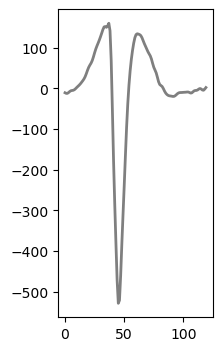

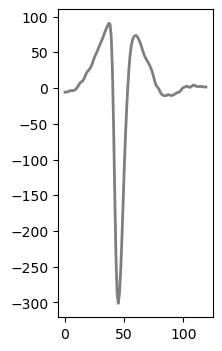

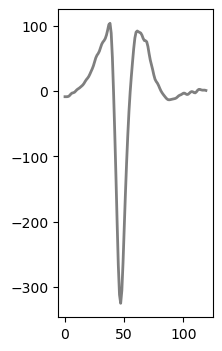

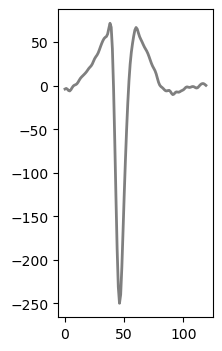

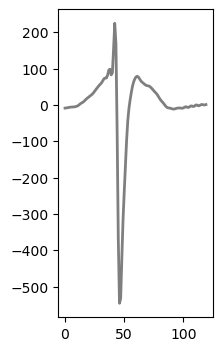

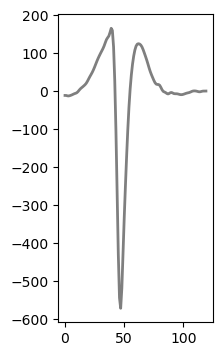

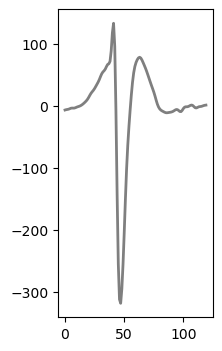

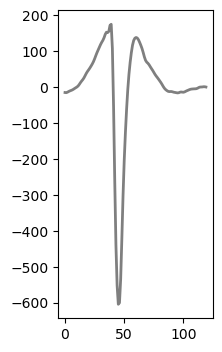

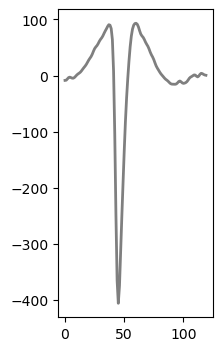

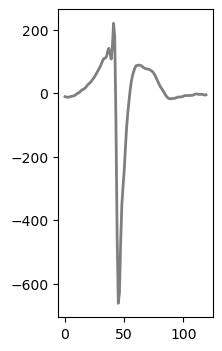

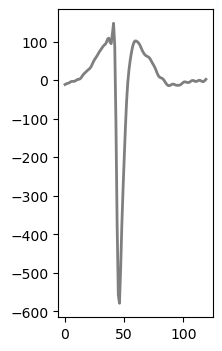

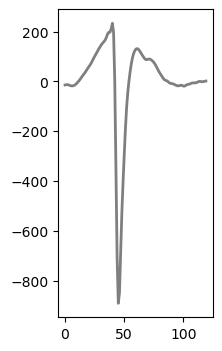

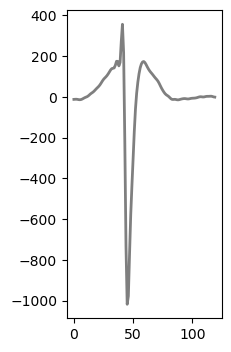

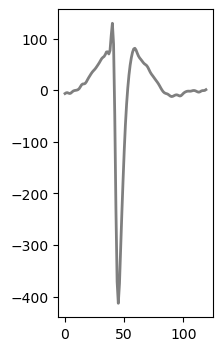

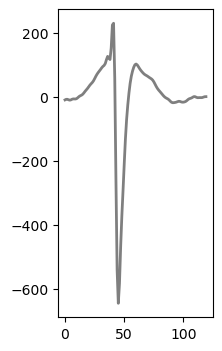

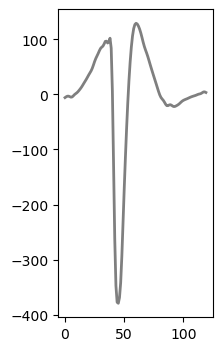

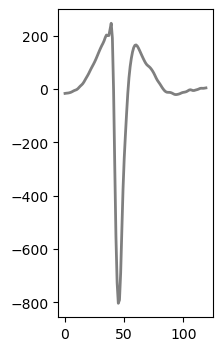

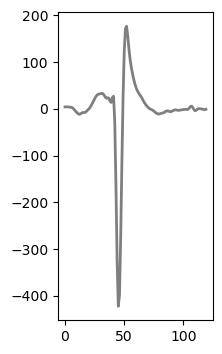

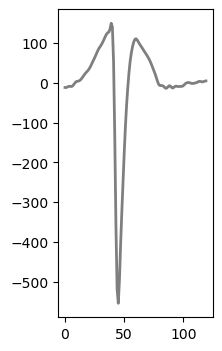

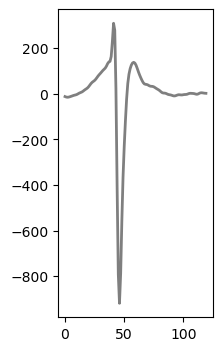

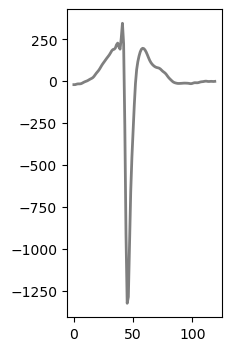

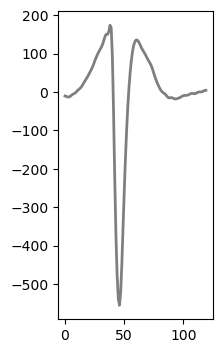

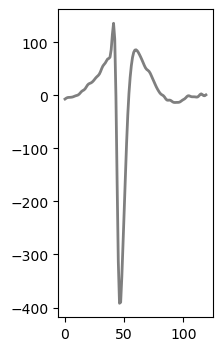

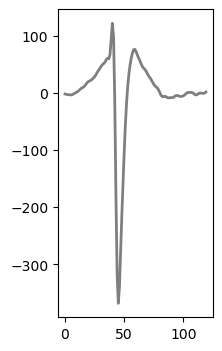

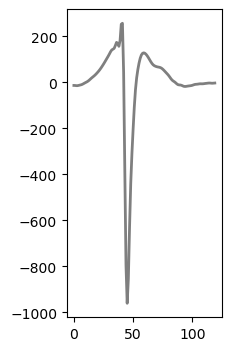

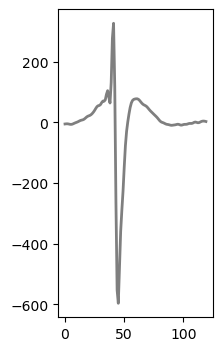

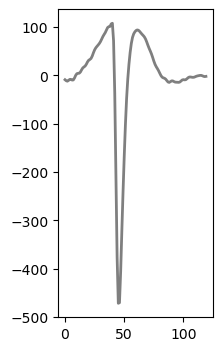

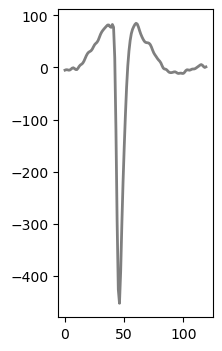

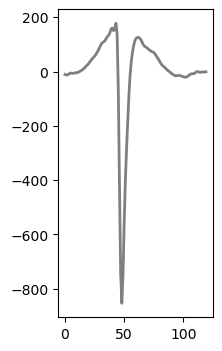

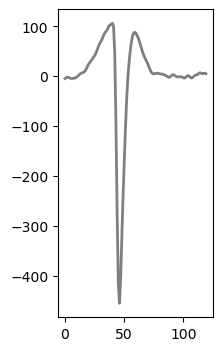

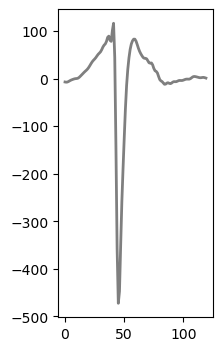

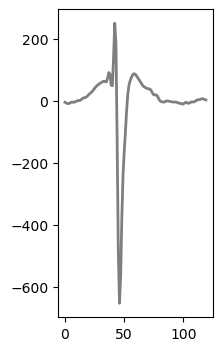

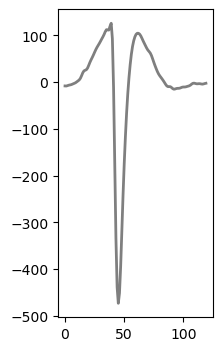

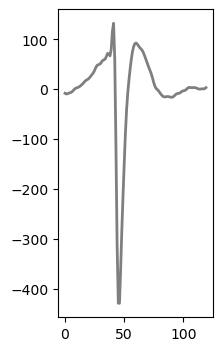

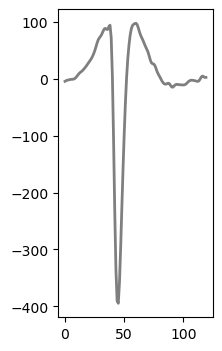

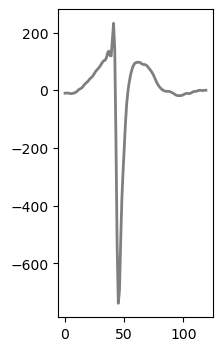

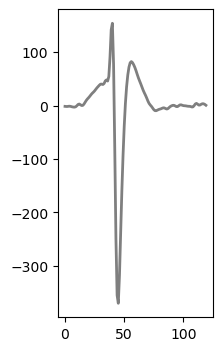

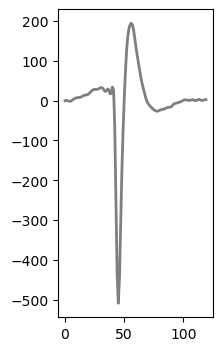

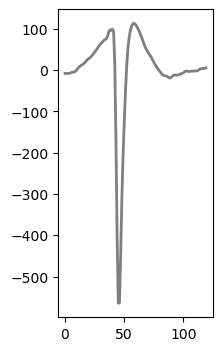

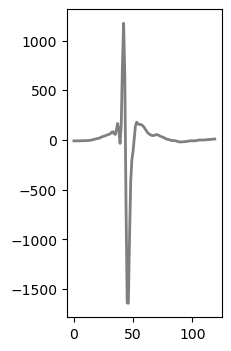

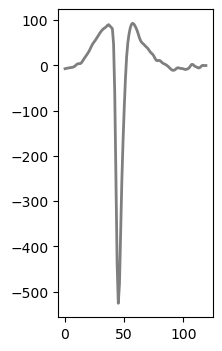

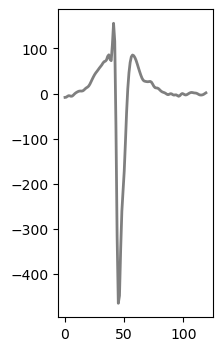

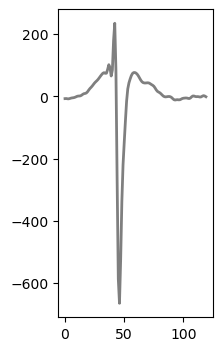

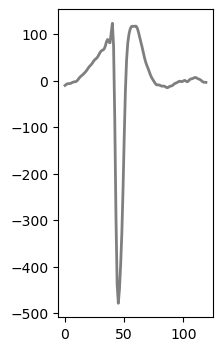

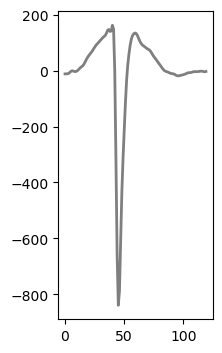

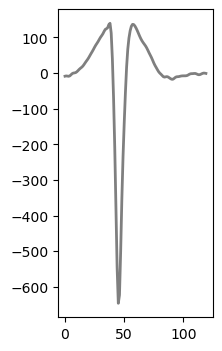

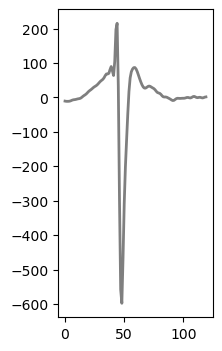

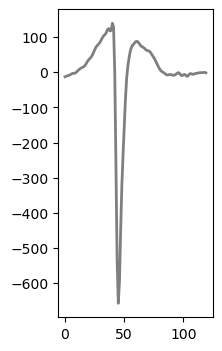

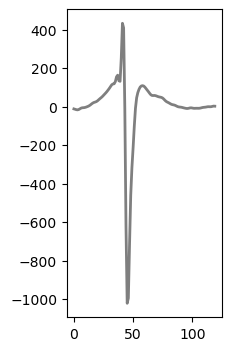

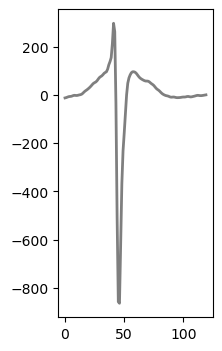

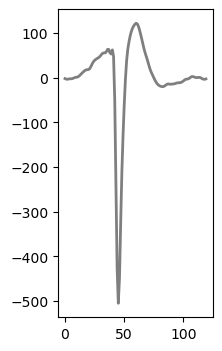

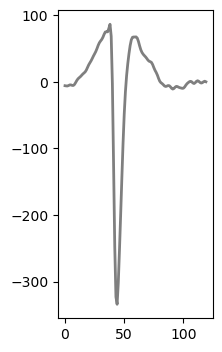

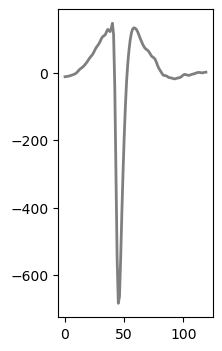

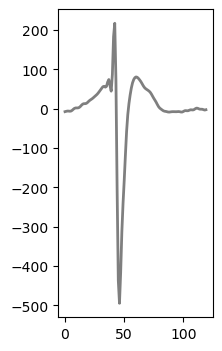

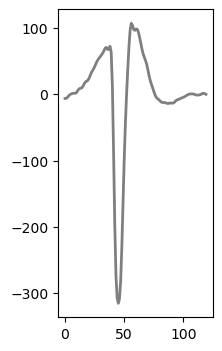

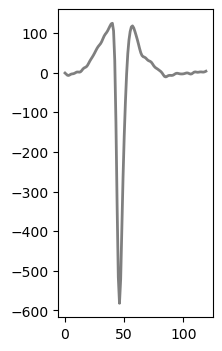

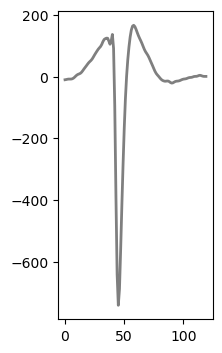

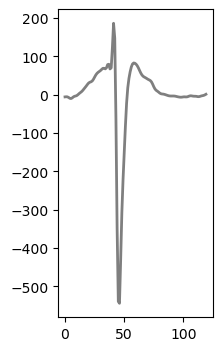

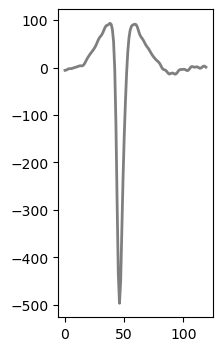

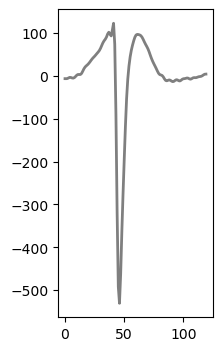

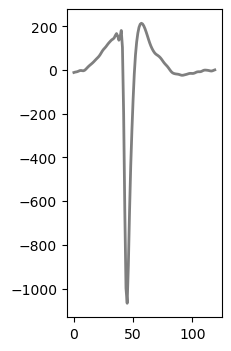

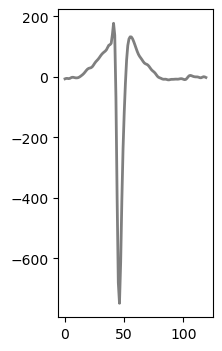

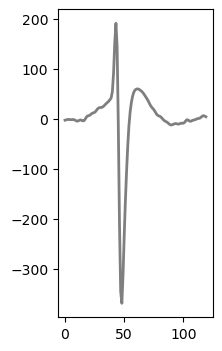

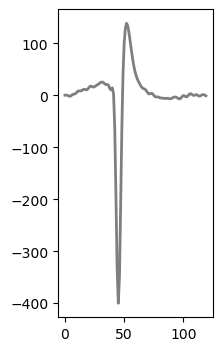

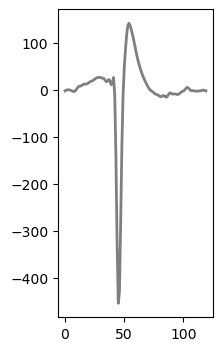

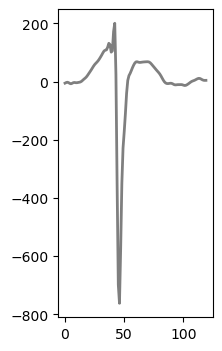

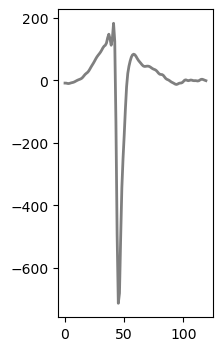

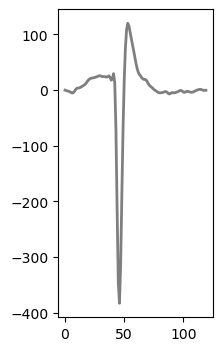

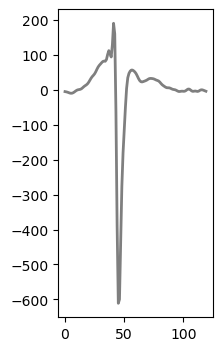

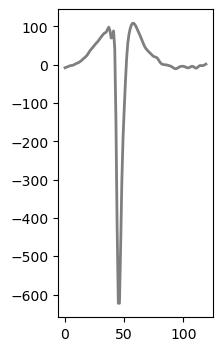

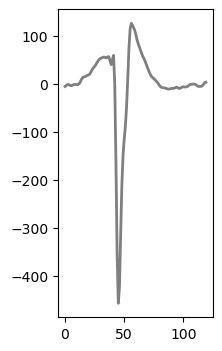

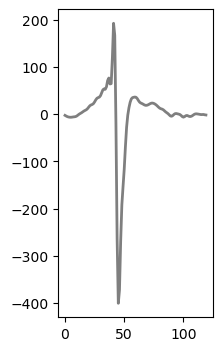

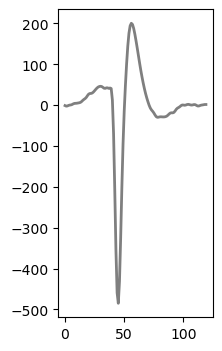

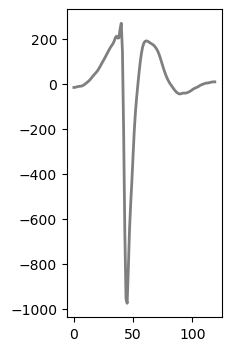

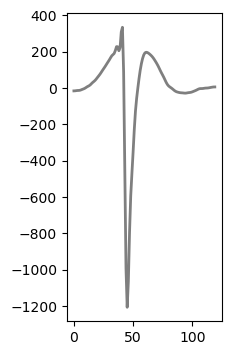

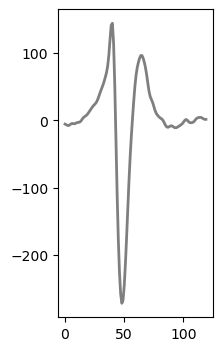

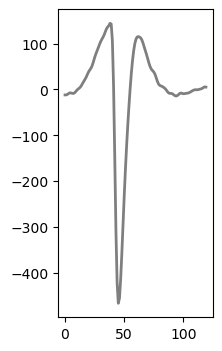

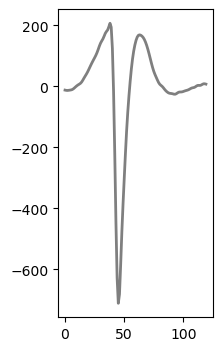

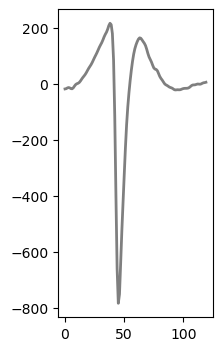

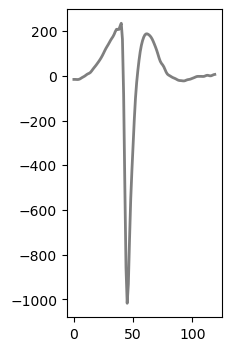

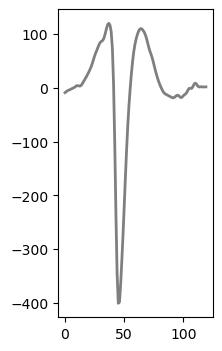

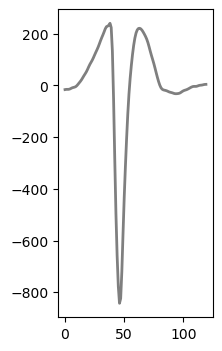

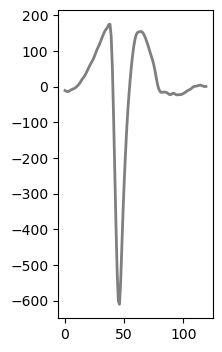

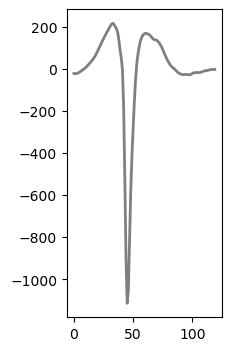

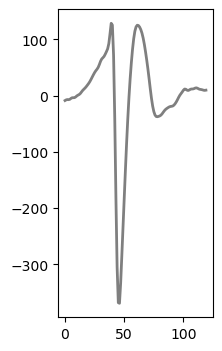

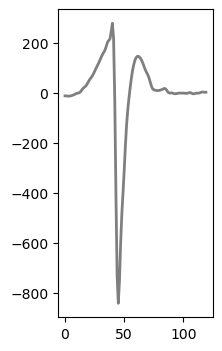

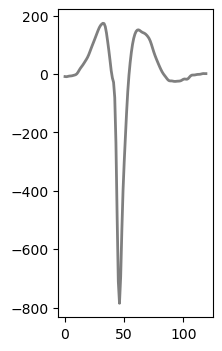

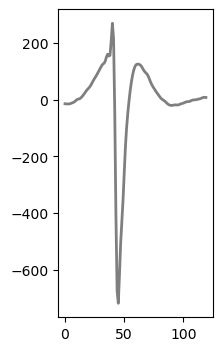

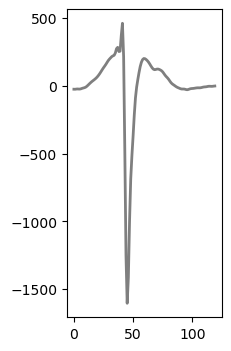

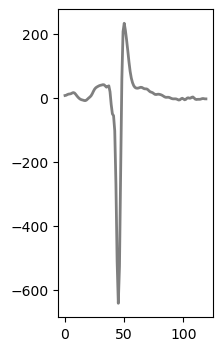

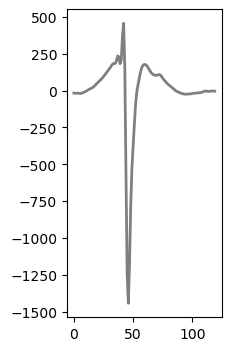

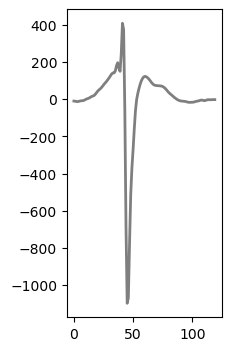

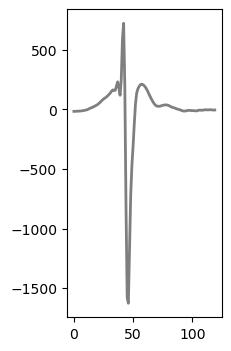

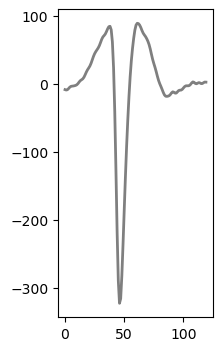

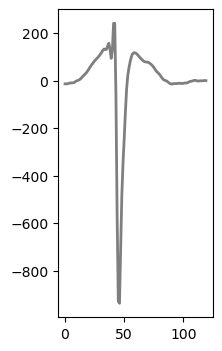

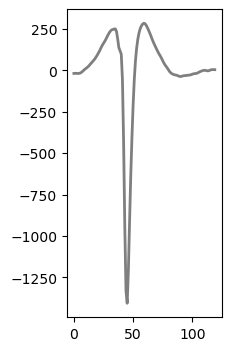

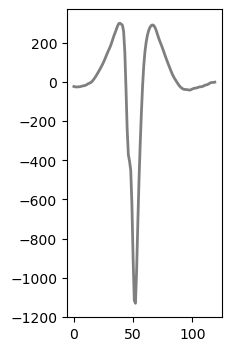

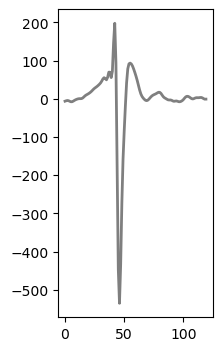

In [4]:
max_site = waveform_struct['max_site'] - 1 # fix matlab indexing
for i in range(n_cells):  
    wf_temp = mean_waveforms[i, max_site[i]]

    f, ax = plt.subplots(1, 1, figsize=(2, 4))
    ax.plot(wf_temp.T, 'k', lw=2, alpha=0.5)
#     plt.title(f'template {i}\nchannel {max_ch[i]}')
    plt.show()

In [5]:
'''
Cluster excitatory vs. inhibitory cells
---------------------------------------
From Payne et al. 2021 Methods

- Spike width: time (ms) from the trough of the avg waveform to the subsequent peak
- Peak amplitude asymmetry: relative height of the two positive peaks flanking the trough
    --> (b-a)/(b+a) where a is the first peak, b is the second
    --> −1 if + 1st peak, - 2nd; 0 when 1st = 2nd; +1 when -1st, + 2nd
- Firing rate (Hz)

Then use k-means clustering on waveforms in this 3D space
'''
# get the waveform properties
all_fr = waveform_struct['meanRate']
all_width = np.zeros(n_cells)
all_assym = np.zeros(n_cells)
for wf_idx in range(n_cells):
    best_ch = max_site[wf_idx]
    all_width[wf_idx] = waveform_analysis.calc_spike_width(mean_waveforms[wf_idx, best_ch])
    all_assym[wf_idx] = waveform_analysis.calc_amp_assym(mean_waveforms[wf_idx, best_ch])    

In [5]:
# for log scaling...
def log_tick_formatter(val, pos=None):
    return f"$10^{{{val:g}}}$"

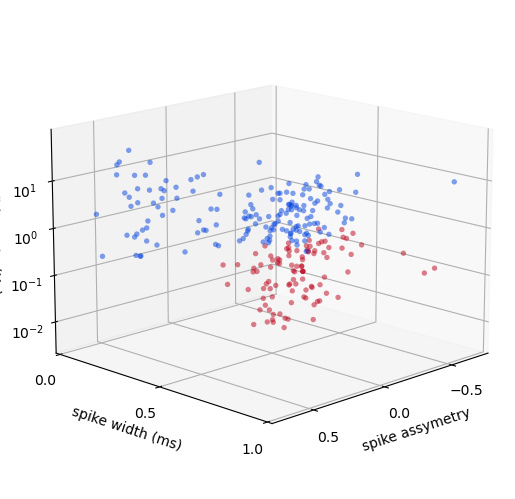

In [21]:
''' plot the waveform properties '''
fig = plt.figure(figsize=(8, 4))
ax = plt.axes([0, 0, .6, 1.2], projection='3d')

clu1_idx = W_raw.astype(bool)
clu2_idx = np.abs(W_raw - 1).astype(bool)

ax.scatter(all_assym[clu1_idx],
           all_width[clu1_idx],
           np.log10(all_fr[clu1_idx]),
           c='xkcd:scarlet', alpha=0.5, lw=0, s=15)

ax.scatter(all_assym[clu2_idx],
           all_width[clu2_idx],
           np.log10(all_fr[clu2_idx]),
           c='xkcd:blue', alpha=0.5, lw=0, s=15)

# labels
ax.set_xlabel('spike assymetry')
ax.set_ylabel('spike width (ms)')
ax.set_zlabel('firing rate (Hz)')

# log scale the z-axis
ax.zaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.zaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# limits
ax.set_xlim([-0.75, 0.75])
ax.set_xticks([-0.5, 0, 0.5])
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])

ax.view_init(azim=45, elev=15)

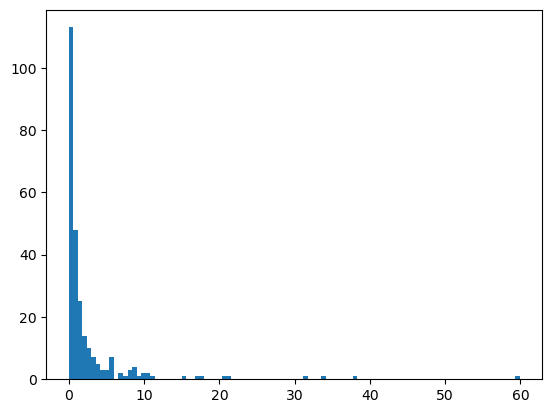

In [7]:
f, ax = plt.subplots(1, 1)
ax.hist(all_fr, bins=100)
plt.show()

In [12]:
wf_params = np.column_stack([all_assym, all_width])
wf_params = np.column_stack([wf_params, all_fr])

In [14]:
''' kmeans cluster on those parameters '''
kmeans = KMeans(n_clusters=2, n_init=100, random_state=1234)
kmeans.fit(wf_params)
H = kmeans.cluster_centers_
W_raw = kmeans.labels_

C:\Users\ilow1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [17]:
np.unique(W_raw)

array([0, 1])